Daniel Iván Lozano Simanca

Samuel Ochoa Alzate

# **Marco Teórico**

Para sustentar estos hallazgos desde un marco teórico sólido, es imperativo comprender la distinción entre señales determinísticas y estocásticas. Mientras que las primeras siguen un modelo matemático exacto y predecible, las señales de origen biológico se rigen por leyes probabilísticas y presentan un grado de incertidumbre intrínseco que obliga al uso de momentos estadísticos de primer y segundo orden. En este contexto, la media aritmética funciona como un indicador de la tendencia central o el nivel de referencia de la señal, mientras que la varianza cuantifica la amplitud de las fluctuaciones de los datos respecto a ese centro, sirviendo como una métrica de la intensidad de la despolarización cardiaca. Complementariamente, el cálculo del valor cuadrático medio o RMS se establece como la herramienta fundamental para medir la potencia promedio o energía contenida en la señal, lo cual es vital para comparar la magnitud de la activación eléctrica independientemente de la polaridad de las ondas registradas.

PARTE 1. ANÁLISIS ESTADÍSTICO DE ECG

In [ ]:
import scipy.stats as stats
from scipy.signal import find_peaks
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def rms(signal):
    n = np.shape(signal)[0]
    rms = np.sqrt(1 / n * np.sum(signal ** 2))
    return rms

def graficar(t, *signals, ejex='Tiempo (s)', ejey='Amplitud', titulo='Señal', 
             labels=None, subplots=False, fs=None):
    """
    Parámetros:
        t        : vector de tiempo
        *signals : una o más señales a graficar
        ejex     : etiqueta eje x
        ejey     : etiqueta eje y
        titulo   : título del gráfico (o lista de títulos si subplots=True)
        labels   : lista de nombres para la leyenda ['ECG', 'Filtrada', ...]
        subplots : False → todas en la misma figura | True → una por subplot
        fs       : si se pasa, el eje x se grafica en tiempo real (t/fs)
    """
    n = len(signals)
    colores = ['steelblue', 'crimson', 'seagreen', 'darkorange', 'mediumpurple']

    if labels is None:
        labels = [f'Señal {i+1}' for i in range(n)]

    if not subplots:
        # 1 subplot, muchas graph
        fig, ax = plt.subplots(figsize=(12, 4))
        for i, sig in enumerate(signals):
            ax.plot(t, sig, color=colores[i % len(colores)], label=labels[i])
        ax.set_title(titulo)
        ax.set_xlabel(ejex)
        ax.set_ylabel(ejey)
        ax.legend()
        ax.grid()

    else:
        # 1 subplot para cada señal
        titulos = titulo if isinstance(titulo, list) else [titulo] * n
        fig, axs = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)
        if n == 1:
            axs = [axs]
        for i, (sig, ax) in enumerate(zip(signals, axs)):
            ax.plot(t, sig, color=colores[i % len(colores)], label=labels[i])
            ax.set_title(titulos[i])
            ax.set_ylabel(ejey)
            ax.legend()
            ax.grid()
        axs[-1].set_xlabel(ejex)

    plt.tight_layout()
    plt.show()

In [6]:
fs = 1024 #Hz
signals = sio.loadmat(r'signals.mat') # cambiar para colab
print(signals.keys())
# 'ECG_asRecording'
# 'EMG_asRecording1'
# 'EMG_asRecording2'

#señal ecg en t
ecg = signals['ECG_asRecording'].flatten()
ecg_filtrada = signals['ECG_filtered'].flatten()


#Vec tiempo
vec_tiempo = np.arange(0, len(ecg))

#señal ecg en freq
freqs = np.fft.fftfreq(len(ecg), d=1/fs)
fft_ecg = np.fft.fft(ecg)
fft_ecg_filtrada = np.fft.fft(ecg_filtrada)


dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


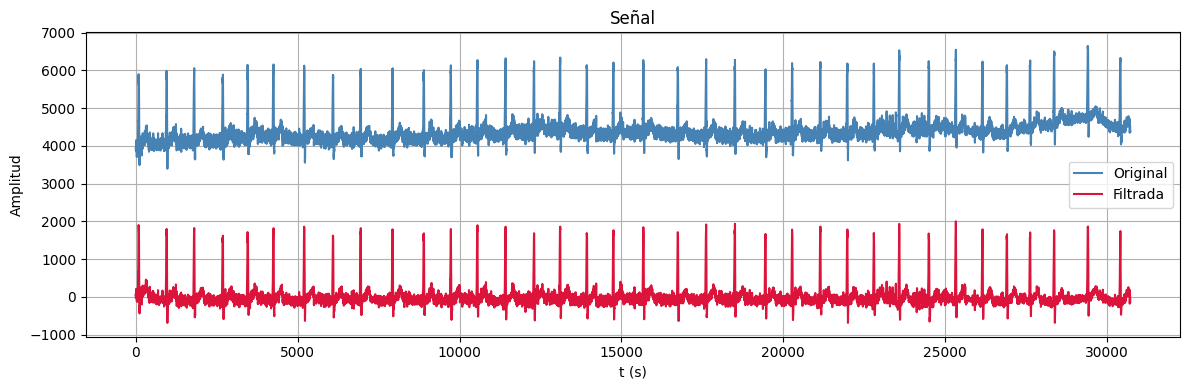

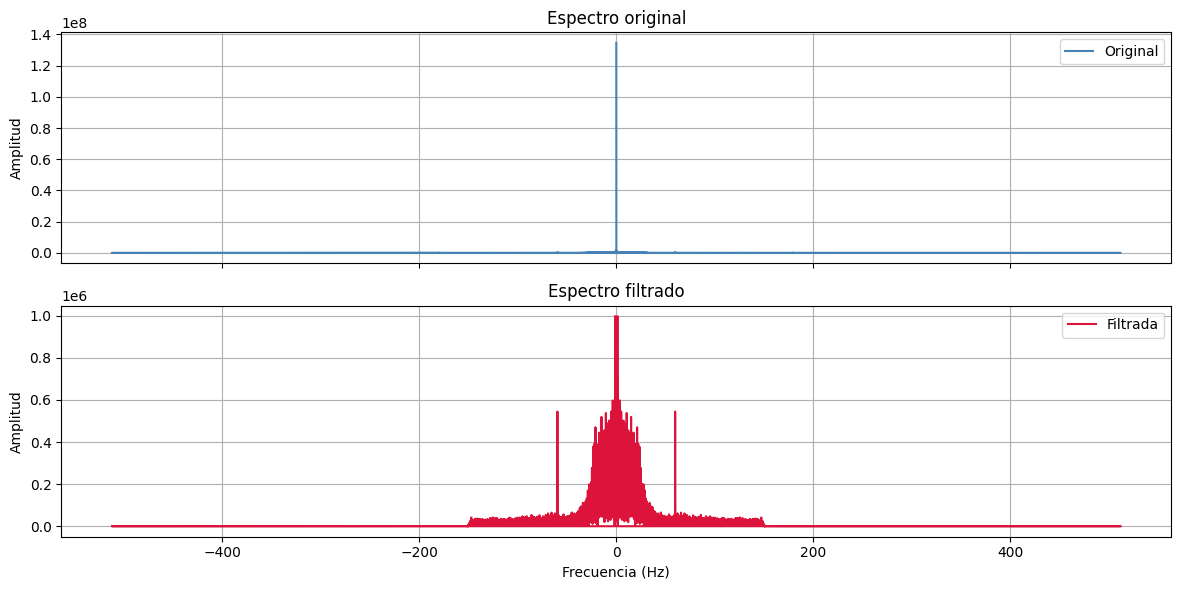

(3904.3168945312495+0j)
(0.008871038954998767-3.031649005909761e-14j)


In [7]:
graficar(vec_tiempo, ecg, ecg_filtrada,
         ejex='t (s)', ejey='Amplitud', titulo='Señal',
         labels=['Original', 'Filtrada'])
graficar(freqs, np.abs(fft_ecg), np.abs(fft_ecg_filtrada),
         ejex='Frecuencia (Hz)', ejey='Amplitud',
         titulo=['Espectro original', 'Espectro filtrado'],
         labels=['Original', 'Filtrada'],
         subplots=True)
#20 * np.log10(np.abs(fft_ecg_filtrada) + 1e-10)
print(np.mean(fft_ecg))
print(np.mean(fft_ecg_filtrada))

EXPLICACIÓN DIFERENCIAS SEÑAL NORMAL + SEÑAL FILTRADA.

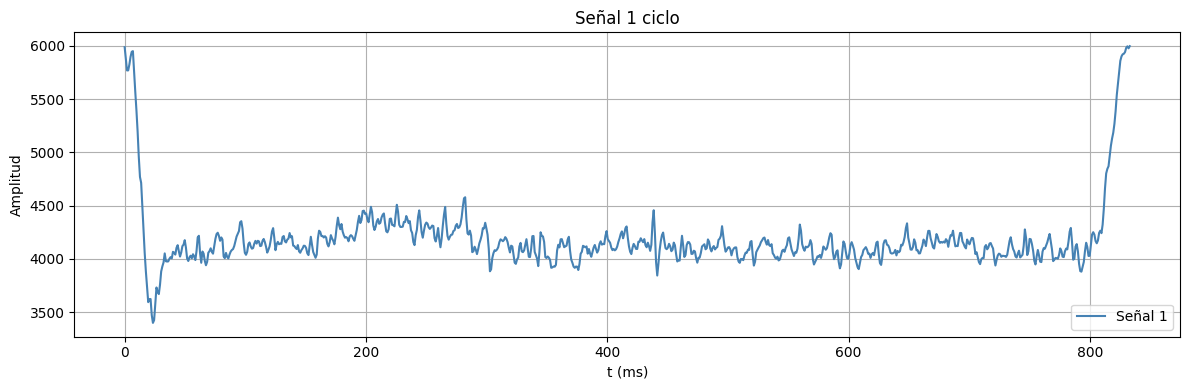

Promedio: 4185.684379059481
RMS: 4198.270214103224
Varianza: 105519.06952377582
Std: 324.83698915575457


In [8]:
picos, _ = find_peaks(ecg, height=np.mean(ecg), distance=fs*0.5)

i = 1
ciclo = ecg[picos[i]: picos[i+1]]
t_ciclo = np.arange(len(ciclo)) / fs*1000 #t span la puse es en milisec

graficar(t_ciclo, ciclo, ejex='t (ms)', ejey='Amplitud', titulo='Señal 1 ciclo')

print(f'Promedio: {np.mean(ciclo)}')
print(f'RMS: {rms(ciclo)}')
print(f'Varianza: {np.var(ciclo)}')
print(f'Std: {np.std(ciclo)}')

ANALISIS RESULTADOS ESTADISTICOS PARA SEÑAL ORIGINAL

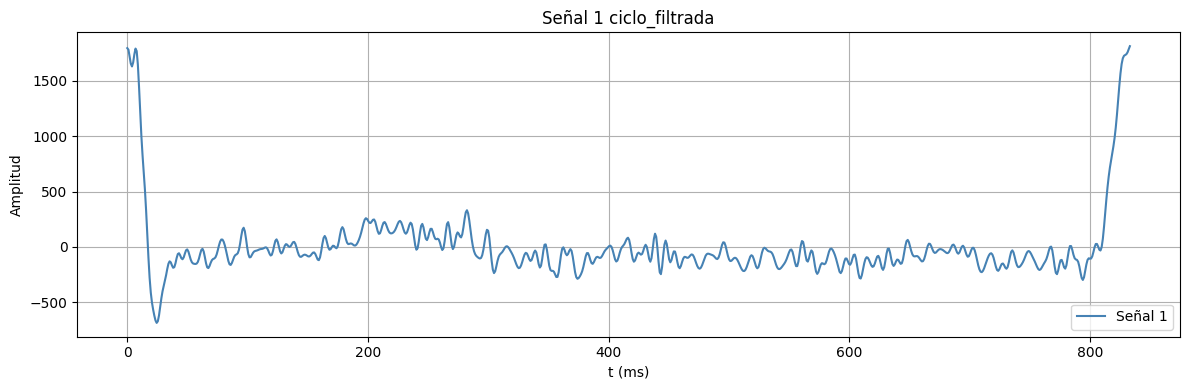

Promedio: -1.4625781779933433
RMS: 323.71685872741466
Varianza: 104790.46548941819
Std: 323.7135546890463


In [9]:
picos_filtrada, _ = find_peaks(ecg_filtrada, height=np.mean(ecg_filtrada), distance=fs*0.5)

i = 1
ciclo_filtrada = ecg_filtrada[picos_filtrada[i]: picos_filtrada[i+1]]
t_ciclo_filtrada = np.arange(len(ciclo_filtrada)) / fs*1000 #t span la puse es en milisec

graficar(t_ciclo, ciclo_filtrada, ejex='t (ms)', ejey='Amplitud', titulo='Señal 1 ciclo_filtrada')

print(f'Promedio: {np.mean(ciclo_filtrada)}')
print(f'RMS: {rms(ciclo_filtrada)}')
print(f'Varianza: {np.var(ciclo_filtrada)}')
print(f'Std: {np.std(ciclo_filtrada)}')

COMPARACIÓN CON RESULTADOS SEÑAL FILTRADA/ SEÑAL ORIGINAL

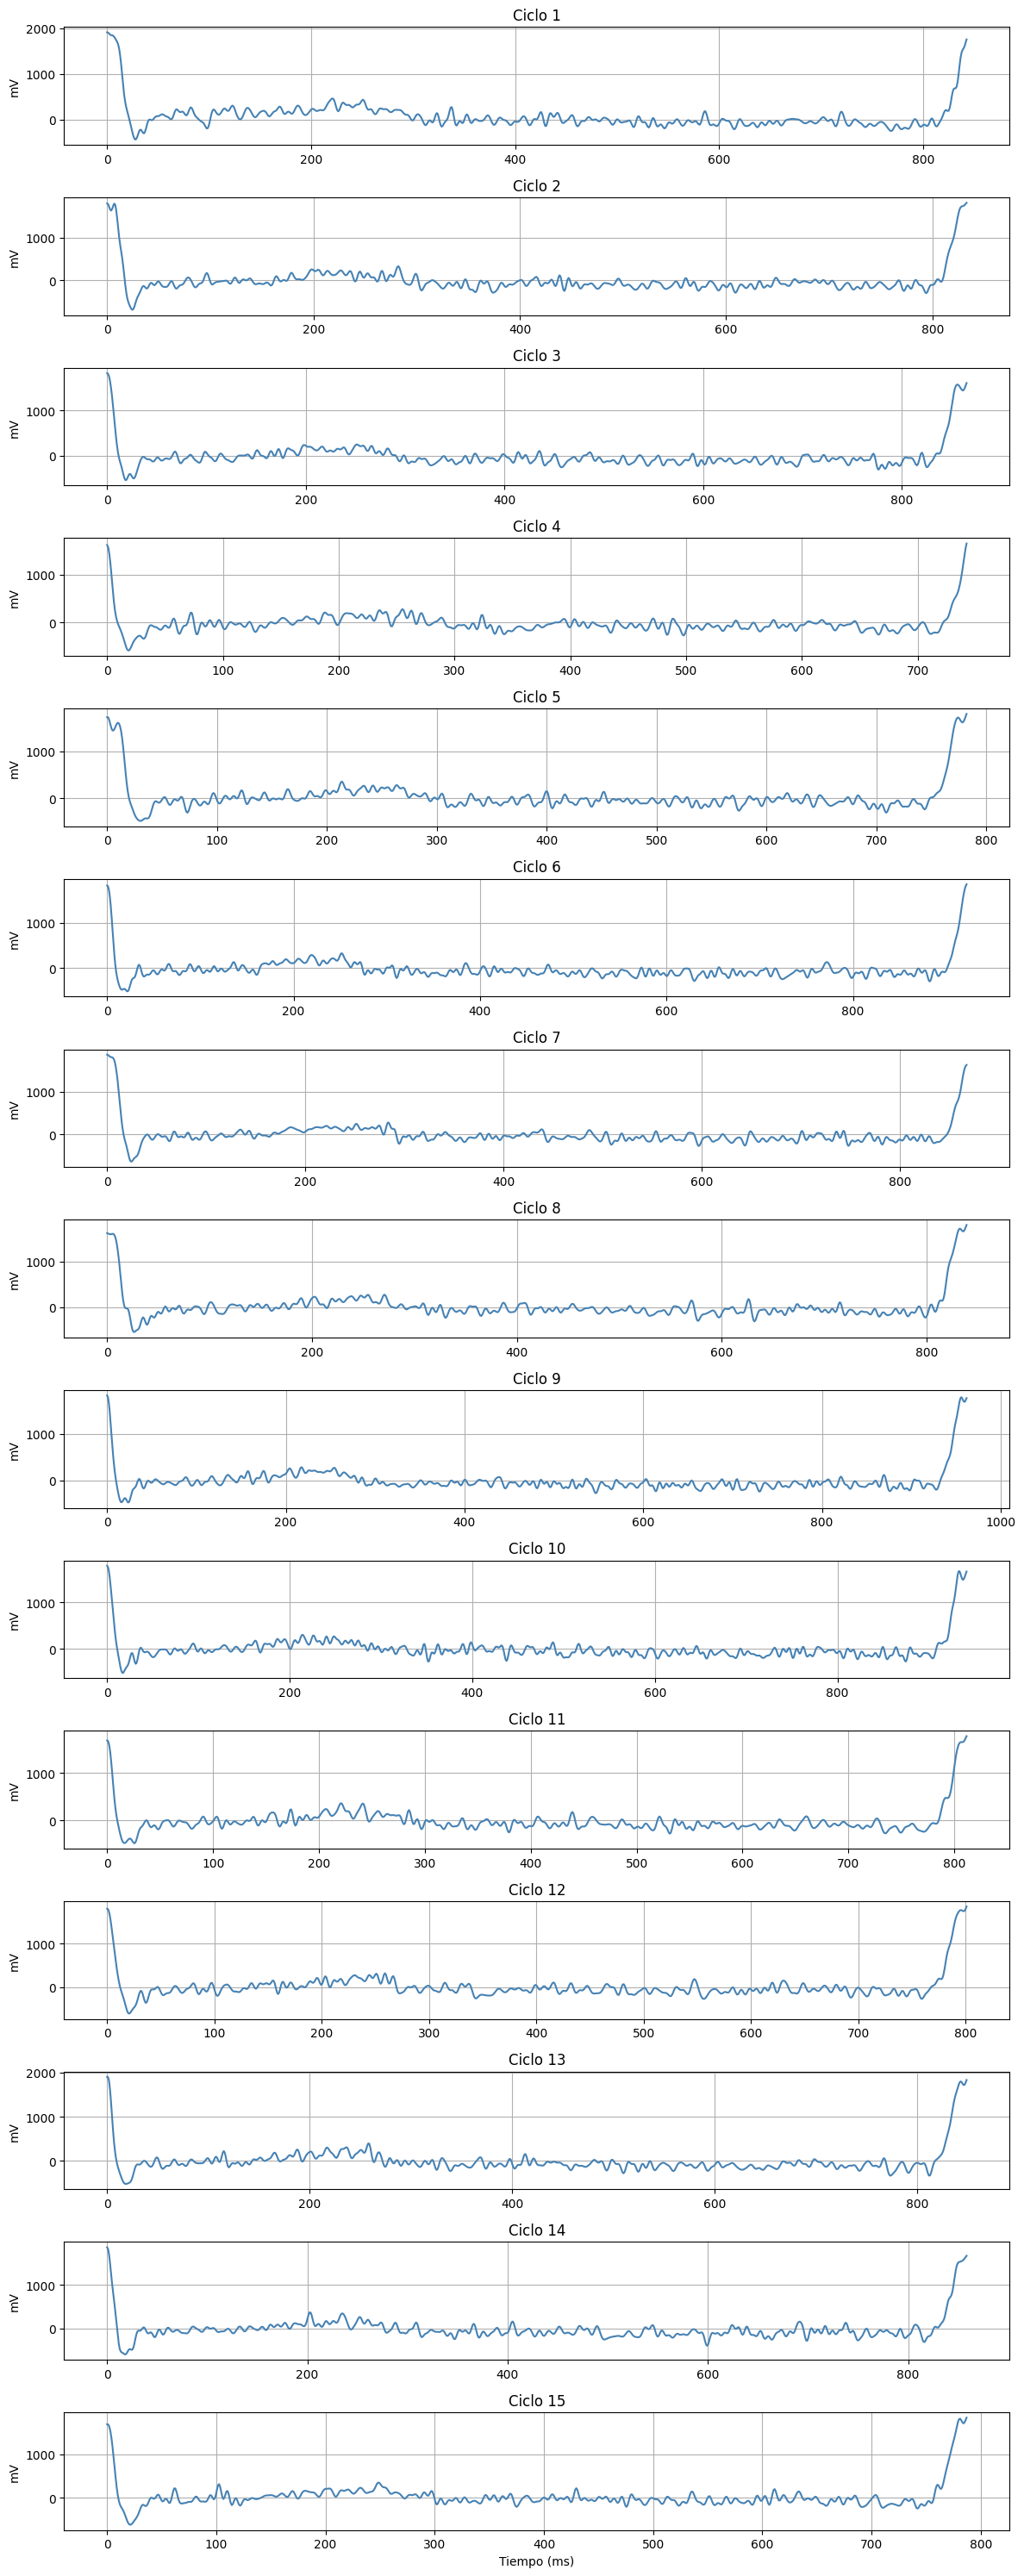

Ciclo 1
Promedio: 74.00995782055861, Varanza: 96684.31488232457
Ciclo 2
Promedio: -1.4625781779933433, Varanza: 104790.46548941819
Ciclo 3
Promedio: -10.433000231133212, Varanza: 82451.25107858983
Ciclo 4
Promedio: -20.975177997377532, Varanza: 46839.01969414558
Ciclo 5
Promedio: 40.87110478533409, Varanza: 114850.02006450474
Ciclo 6
Promedio: -27.94373421958412, Varanza: 58147.589511512415
Ciclo 7
Promedio: 0.43078685936823324, Varanza: 77707.28120177508
Ciclo 8
Promedio: 21.40785342744196, Varanza: 100268.18152771876
Ciclo 9
Promedio: -10.175289840749373, Varanza: 71784.95578593282
Ciclo 10
Promedio: 8.81210265962322, Varanza: 68481.05976260055
Ciclo 11
Promedio: -8.906158250191359, Varanza: 76088.38489781879
Ciclo 12
Promedio: 13.21327398140507, Varanza: 93862.69588330528
Ciclo 13
Promedio: -4.203262548456708, Varanza: 87951.50447594067
Ciclo 14
Promedio: -14.969688987125844, Varanza: 77022.13291729224
Ciclo 15
Promedio: 27.108316233516877, Varanza: 89636.93559971548


In [10]:
ciclos = []
for i in range(15):
    ciclos.append(ecg_filtrada[picos_filtrada[i]: picos_filtrada[i+1]])

#def graficar no sirvió
fig, axs = plt.subplots(15, 1, figsize=(12, 30), sharex=False)

for i, (ciclo, ax) in enumerate(zip(ciclos, axs)):
    t_ciclo = np.arange(len(ciclo)) / fs * 1000  # en ms
    ax.plot(t_ciclo, ciclo, color='steelblue')
    ax.set_title(f'Ciclo {i+1}')
    ax.set_ylabel('mV')
    ax.grid()

axs[-1].set_xlabel('Tiempo (ms)')
plt.tight_layout()
plt.show()

#estadistica
estadisticas = [[np.mean(ciclo), np.var(ciclo)] for ciclo in ciclos]
for indice, elemento in enumerate(estadisticas):
    print(f'Ciclo {indice + 1}')
    print(f'Promedio: {elemento[0]}, Varanza: {elemento[1]}')

LA SEÑAL ES ESTACIONARIA?

In [11]:
#ANALISIS 2 CICLOS CON PRUEBA T

#Numero de muestras para mis ciclos?
ciclo_1 = ciclos[0] #864
ciclo_2 = ciclos[4] #802

#Son large sample numbers (>500), entonces Kolmogorov-Smirnov test para normalidad

def check_normality(ciclo1, ciclo2):
    '''Check if the distribution is normal.'''

    pVals1 = pd.Series()
    pVals2 = pd.Series()

    # Kolmogorov-Smirnov test (recommended for large samples n > 50)
    _, pVals1['Kolmogorov-Smirnov'] = stats.kstest((ciclo1 - np.mean(ciclo1)) / np.std(ciclo1, ddof=1), 'norm')
    _, pVals2['Kolmogorov-Smirnov'] = stats.kstest((ciclo2 - np.mean(ciclo2)) / np.std(ciclo2, ddof=1), 'norm')

    print('p-values for cycle 1 ({0} samples): ----------------'.format(len(ciclo1)))
    print(pVals1)
    print('p-values for cycle 2 ({0} samples): ----------------'.format(len(ciclo2)))
    print(pVals2)

    if pVals1['Kolmogorov-Smirnov'] > 0.05:
        print('Distribución normal para ciclo 1')
    if pVals2['Kolmogorov-Smirnov'] > 0.05:
        print('Distribución normal para ciclo 2')

    return pVals1['Kolmogorov-Smirnov'], pVals2['Kolmogorov-Smirnov']

check_normality(ciclo_1, ciclo_2)

p-values for cycle 1 (864 samples): ----------------
Kolmogorov-Smirnov    5.065173e-26
dtype: float64
p-values for cycle 2 (802 samples): ----------------
Kolmogorov-Smirnov    1.686959e-44
dtype: float64


(np.float64(5.065173284518871e-26), np.float64(1.686958747319659e-44))

Ninguno de los 2 ciclos escogidos cumple con tener distribución normal, por lo tanto, no se puede aplicar prueba t y tenemos que escoger pruebas paramétricas que no asumen normalidad.

Se procede a realizar la prueba estadística Mann-Whitney para estos 2 "ciclo_1" y "ciclo_2" escogidos.

In [12]:
from scipy.stats import mannwhitneyu

# compare samples
stat, p = mannwhitneyu(ciclo_1, ciclo_2)
print('Statistics=%.3f, p=%.3f' % (stat, p))
# interpret
alpha = 0.05
if p > alpha:
    print('Same distribution (fail to reject H0)')
else:
    print('Different distribution (reject H0)')

Statistics=396841.000, p=0.000
Different distribution (reject H0)


La prueba arrojó U = 396,841 y p ≈ 0.000 (p << 0.05), por lo que se rechaza H_null. Esto indica que los dos ciclos de ECG provienen de distribuciones significativamente diferentes.

Mann-Whitney lo que hace es comparar si los valores de un ciclo tienden a ser sistemáticamente mayores o menores que los del otro. Un resultado significativo sugiere que la morfología o amplitud entre los dos ciclos no es la misma. Desde el punto de vista fisiológico, esto puede no tener mucho sentido debido a la naturaleza pseudo-periódica del ciclo cardiaco. Ahora, una de las posibles razones debido a la presencia de distribuciones significativamente diferentes puede ser por ruidos no filtrados satisfactoriamente que sean variantes en el tiempo, especialmente entre ciclo y ciclo; otra razón pueden ser cambios fisiológicos ocurridos entre los intervalos, dados por causas naturales en el paciente a la hora de ser medidos, o por anomalías como por ejemplo arritmias.

DICKEY FULLER PARA ESTACIONARIEDAD

In [19]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------- ----------- 6.8/9.5 MB 59.3 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 57.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [stat

In [16]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ecg_filtrada)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
if result[1] < 0.05:
    print('La senal es estacionaria')
else:
    print('La senal no es estacionaria')

ADF Statistic: -26.612453
p-value: 0.000000
La senal es estacionaria
